##  Feature extraction


In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/final_combined_anamoly_scores.csv')

In [ ]:
df.shape

(144233, 618)

In [ ]:
df.head()

,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_13,...,card6_freq,P_emaildomain_freq,R_emaildomain_freq,M4_freq,isFraud,ae_score,ae_bin,ae_percentile,very_high_ae,iso_score
0,0.0,70787.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,100.0,-1.0,...,0.523504,0.376614,0.105559,0.596650,0,0.057046,"(0.0546, 0.0648]",0.425596,0,-0.060638
1,-5.0,98945.0,-1.0,-1.0,0.0,-5.0,-1.0,-1.0,100.0,49.0,...,0.475794,0.125578,0.105559,0.596650,0,0.053549,"(0.0459, 0.0546]",0.389009,0,-0.063080
2,-5.0,191631.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,52.0,...,0.523504,0.376614,0.375600,0.069913,0,0.159989,"(0.131, 0.209]",0.849750,0,0.004278
3,-5.0,221832.0,-1.0,-1.0,0.0,-6.0,-1.0,-1.0,100.0,52.0,...,0.475794,0.177197,0.170558,0.069913,0,0.052416,"(0.0459, 0.0546]",0.376675,0,-0.063576
4,0.0,7460.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,-1.0,...,0.475794,0.032188,0.105559,0.596650,0,0.058955,"(0.0546, 0.0648]",0.444572,0,-0.062568


now we gonna split based upon the transaction time and here it is calculated based uopn some reference and everything will be in seconds
<br>
we are splitting the data based upon the **transaction time stamp**<br>
models are always trained on past data and used to predict future transactions.<br>
Therefore, instead of doing a random split, I sorted the dataset by TransactionDT and performed a time-based 80/20 split. This prevents data leakage, ensures realistic evaluation, and better simulates how the model would perform in a live environment.
<br>
A random split could mix future fraud patterns into the training data, leading to overly optimistic validation performance and poor generalization in production.

In [ ]:
# Sort dataset by time
df = df.sort_values('TransactionDT').reset_index(drop=True)
df1=df['TransactionDT']
cols=['TransactionDT','ae_bin']
df=df.drop(columns=cols)

In [ ]:
# Compute split index (80%)
split_index = int(len(df) * 0.8)


# Split dataset
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (115386, 616)
Test shape: (28847, 616)


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Separate features and target
X_train = train_df.drop(columns=['isFraud'])
y_train = train_df['isFraud']

X_test = test_df.drop(columns=['isFraud'])
y_test = test_df['isFraud']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (115386, 615)
X_test: (28847, 615)


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [ ]:
import xgboost as xgb

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc, prec, rec, auc = [], [], [], []
feature_importance = np.zeros(X_train.shape[1])

for train_idx, val_idx in kf.split(X_train, y_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    acc.append(accuracy_score(y_val, preds))
    prec.append(precision_score(y_val, preds))
    rec.append(recall_score(y_val, preds))
    auc.append(roc_auc_score(y_val, probs))

    feature_importance += model.feature_importances_

# Average importance
feature_importance /= 5

print("XGBoost CV Results")
print("Accuracy:", np.mean(acc))
print("Precision:", np.mean(prec))
print("Recall:", np.mean(rec))
print("AUC:", np.mean(auc))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:28:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:28:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:29:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:29:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV Results
Accuracy: 0.9788882502552158
Precision: 0.9260520305574875
Recall: 0.7805910730583685
AUC: 0.9882750333377878


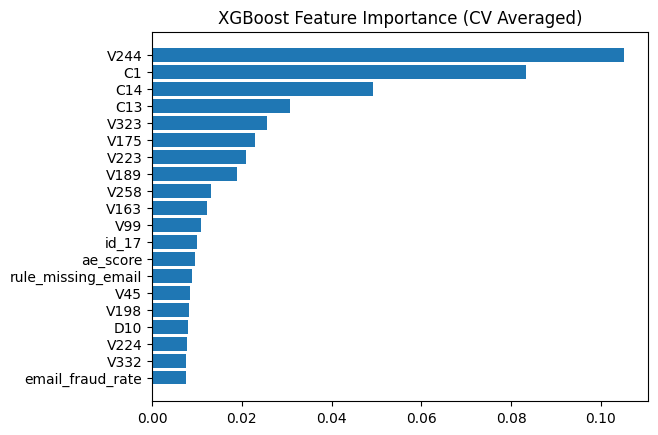

In [ ]:
import matplotlib.pyplot as plt

# Create a DataFrame for feature importance
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

top20 = xgb_importance.head(20)

plt.figure()
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (CV Averaged)")
plt.show()

In [ ]:
# Number of features to drop (last 20%)
n_drop = int(0.2 * len(xgb_importance))

# Get bottom 20% features
xgb_bottom_20 = xgb_importance.tail(n_drop)

print("XGBoost - Bottom 20% Features:")
print(xgb_bottom_20["feature"].values)

# Drop from dataset
X_train_xgb = X_train.drop(columns=xgb_bottom_20["feature"])
X_test_xgb  = X_test.drop(columns=xgb_bottom_20["feature"])

print("New shape after dropping (XGBoost):", X_train_xgb.shape)

XGBoost - Bottom 20% Features:
['V98' 'V100' 'V103' 'V104' 'V106' 'rule_night_txn' 'rule_email_score'
 'V25' 'V27' 'V28' 'V29' 'V241' 'V240' 'V53_is_missing'
 'rule_high_velocity' 'rule_card_velocity' 'rule_addr_missing'
 'rule_device_change' 'rule_id_missing' 'rule_risky_product'
 'rule_high_C2' 'rule_score_norm' 'id_04_is_missing' 'id_09_is_missing'
 'id_10_is_missing' 'id_13_is_missing' 'id_18_is_missing'
 'id_32_is_missing' 'addr1_is_missing' 'V30' 'V338_is_missing'
 'ae_percentile' 'V333_is_missing' 'V334_is_missing' 'V335_is_missing'
 'V261_is_missing' 'V262_is_missing' 'V263_is_missing' 'V264_is_missing'
 'V265_is_missing' 'V266_is_missing' 'V267_is_missing' 'V268_is_missing'
 'V269_is_missing' 'V91' 'V274_is_missing' 'V275_is_missing'
 'V276_is_missing' 'V277_is_missing' 'V337_is_missing' 'V68' 'V69' 'V70'
 'V75' 'V41' 'V48' 'V325' 'V83' 'V89' 'V90' 'V273_is_missing'
 'V31_is_missing' 'V32_is_missing' 'V33_is_missing' 'V34_is_missing'
 'V35_is_missing' 'V36_is_missing' 'V37_is_

In [ ]:
import pandas as pd

# Combine train features and target
train_final_df = X_train_xgb.copy()
train_final_df["isFraud"] = y_train.values

# Combine test features and target
test_final_df = X_test_xgb.copy()
test_final_df["isFraud"] = y_test.values

print("Train dataset shape:", train_final_df.shape)
print("Test dataset shape:", test_final_df.shape)

Train dataset shape: (115386, 493)
Test dataset shape: (28847, 493)


In [ ]:
final_dataset = pd.concat([train_final_df, test_final_df], axis=0).reset_index(drop=True)
final_dataset=pd.concat([final_dataset,df1],axis=1)
print("Final combined dataset shape:", final_dataset.shape)

Final combined dataset shape: (144233, 494)


In [ ]:
final_dataset.to_csv("final_dataset_after_feature_selection_in_xgboost.csv", index=False)

## Hyper Parameter Tuning


In [ ]:
!pip install xgboost optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale Pos Weight:", scale_pos_weight)

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
def objective(trial):

    param = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",  # faster
        "booster": "gbtree",
        "lambda": trial.suggest_loguniform("lambda", 1e-3, 10.0),
        "alpha": trial.suggest_loguniform("alpha", 1e-3, 10.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
        "n_jobs": -1
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    # Use the global X_train_xgb and y_train for splitting
    for train_idx, valid_idx in skf.split(X_train_xgb, y_train):

        # Assign local variables for the current fold's training and validation sets
        X_fold_train, X_fold_valid = X_train_xgb.iloc[train_idx], X_train_xgb.iloc[valid_idx]
        y_fold_train, y_fold_valid = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = xgb.XGBClassifier(**param)

        model.fit(
            X_fold_train,
            y_fold_train,
            eval_set=[(X_fold_valid, y_fold_valid)],
            verbose=False
        )

        preds = model.predict_proba(X_fold_valid)[:, 1]
        auc = roc_auc_score(y_fold_valid, preds)
        auc_scores.append(auc)

    return np.mean(auc_scores)

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  # increase to 100+ for better results
